In [1]:
from data.weather_fetch import write_query_config, fetch_and_save
from data.preprocess_311 import preprocess_311

In [4]:
import os
outs = preprocess_311(['data/csv_data/' + f for f in os.listdir('data/csv_data')])

Reading data/csv_data/311_City_Service_Requests_in_2022.csv …
Reading data/csv_data/311_City_Service_Requests_in_2023.csv …
Reading data/csv_data/311_City_Service_Requests_in_2024.csv …
Reading data/csv_data/311_City_Service_Requests_in_2021.csv …
Reading data/csv_data/311_City_Service_Requests_in_2025.csv …
  Combined: 17,405 Pothole rows across wards: ['Null', 'Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']
  Wrote data/311_data/null_potholes_20210101_20251231.parquet  (260 rows)  centroid=(38.917929, -77.014602)
  Wrote data/311_data/ward1_potholes_20210101_20251231.parquet  (1,419 rows)  centroid=(38.926030, -77.031193)
  Wrote data/311_data/ward2_potholes_20210101_20251231.parquet  (2,085 rows)  centroid=(38.904732, -77.042980)
  Wrote data/311_data/ward3_potholes_20210101_20251231.parquet  (3,192 rows)  centroid=(38.943303, -77.078361)
  Wrote data/311_data/ward4_potholes_20210101_20251231.parquet  (2,315 rows)  centroid=(38.960461, -77.030698)
  W

In [5]:
# inspect outs 
wards = [f'ward{i}' for i in range(1, 9)]
for ward in wards: 
    lat, lon = outs[ward][1], outs[ward][2]
    # write a query config 
    query_config = write_query_config(ward, lat, lon, '2020-06-01', '2025-12-31')
    _, _ = fetch_and_save(query_config)

Config written → data/weather_query_configs/weather_ward1_20200601_20251231.json
Cache hit — loaded data/weather_cache/weather_ward1_20200601_20251231.parquet
  Saved at: 2026-03-20T19:47:49.109445+00:00
Config written → data/weather_query_configs/weather_ward2_20200601_20251231.json
Cache hit — loaded data/weather_cache/weather_ward2_20200601_20251231.parquet
  Saved at: 2026-03-20T19:47:49.960719+00:00
Config written → data/weather_query_configs/weather_ward3_20200601_20251231.json
Cache hit — loaded data/weather_cache/weather_ward3_20200601_20251231.parquet
  Saved at: 2026-03-20T19:47:50.852019+00:00
Config written → data/weather_query_configs/weather_ward4_20200601_20251231.json
Cache hit — loaded data/weather_cache/weather_ward4_20200601_20251231.parquet
  Saved at: 2026-03-20T19:47:51.689430+00:00
Config written → data/weather_query_configs/weather_ward5_20200601_20251231.json
Cache hit — loaded data/weather_cache/weather_ward5_20200601_20251231.parquet
  Saved at: 2026-03-20T19

In [6]:
# visualize the entire pothole requests data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_parquet('data/311_data/ward3_potholes_20210101_20251231.parquet')
df.head()

,ADDDATE,WARD,SERVICECODEDESCRIPTION
0,2022-01-01 18:00:40+00:00,Ward 3,Pothole
1,2022-01-02 15:26:46+00:00,Ward 3,Pothole
2,2022-01-02 16:58:07+00:00,Ward 3,Pothole
3,2022-01-02 16:58:49+00:00,Ward 3,Pothole
4,2022-01-05 18:44:40+00:00,Ward 3,Pothole


In [7]:
len(pd.to_datetime(df['ADDDATE']).dt.date.unique())

1249

Text(0.5, 1.0, 'Pothole Requests Over Time')

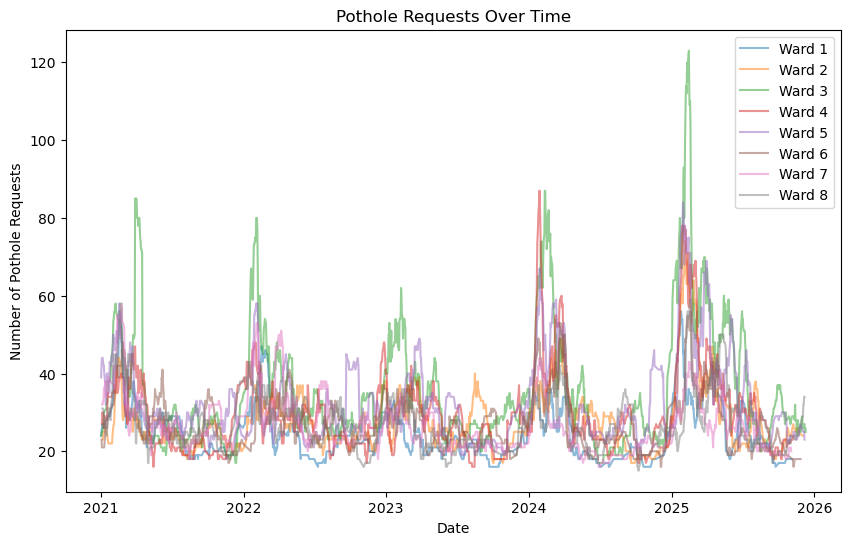

In [8]:
ward_parquets = [f'data/311_data/ward{i}_potholes_20210101_20251231.parquet' for i in range(1, 9)]
def process_pothole_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("ADDDATE")
    df['DATE'] = pd.to_datetime(df['ADDDATE']).dt.date
    potholes_daily = df.groupby('DATE').size()
    return potholes_daily

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for idx, f in enumerate(ward_parquets):
    ward_name = f'Ward {idx + 1}'
    df = pd.read_parquet(f)
    potholes_daily = process_pothole_data(df)
    ax.plot(potholes_daily.index, potholes_daily.rolling(15).sum().shift(-14), 
            label=ward_name, alpha=0.5)
ax.legend()
plt.xlabel('Date')
plt.ylabel('Number of Pothole Requests')
plt.title('Pothole Requests Over Time')

Text(0.5, 1.0, 'Pothole Requests Over Time')

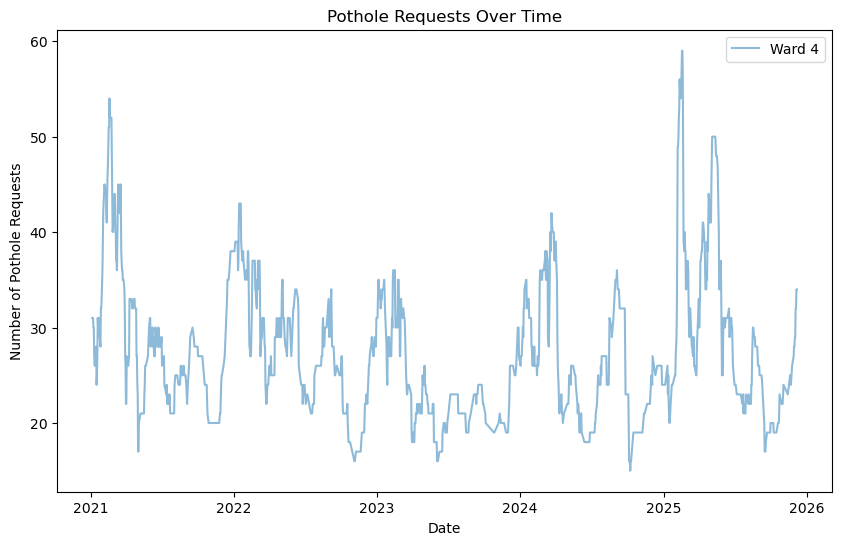

In [9]:
# ward 3 trend 
idx = 3 

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ward_name = f'Ward {idx + 1}'
df = pd.read_parquet(f)
potholes_daily = process_pothole_data(df)
ax.plot(potholes_daily.index, potholes_daily.rolling(15).sum().shift(-14), 
        label=ward_name, alpha=0.5)
ax.legend()
plt.xlabel('Date')
plt.ylabel('Number of Pothole Requests')
plt.title('Pothole Requests Over Time')